# Business Analytics Course Project: Brazilian E-Commerce Analysis 
**Course Project:** Business Analytics Final Project  

---

## Notebook Overview
This notebook represents the end-to-end analytical implementation of our e-commerce business analytics project. It is structured into two main parts:
1. **Phase 2: Data Profiling & Exploratory Data Analysis (EDA)** — Programmatic cleaning, profiling, outlier handling, and correlation mapping.
2. **Phase 3: Answering the Business Questions** — Full Python code, custom visualizations, and strategic business interpretations for our 7 focused questions (Q1–Q5 and Ad Hoc Q6–Q7) as adopted from our Phase 1 guidelines.

# Phase 2: Data Profiling & Exploratory Data Analysis (EDA)
In this phase, we establish our imports, load our relationally unified granular dataset, analyze missing values, detect outliers using the Interquartile Range (IQR) method, and inspect correlation heatmaps.

In [99]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler

# Set premium Seaborn visualization styling
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 12
plt.rcParams["axes.labelsize"] = 12
plt.rcParams["axes.titlesize"] = 14

### 1. Data Loading & Initial Inspection
We load our corrected order-item granular dataset (`../olist_granular_dataset.csv`), rename the raw columns to our target analytical schema, and run initial structural profiling.

In [100]:
import os
# Bulletproof auto-detecting path finder for the Olist dataset
target_file = 'olist_granular_dataset.csv'
possible_paths = [
    'Dataset/' + target_file,
    'Final/Dataset/' + target_file,
    '../Dataset/' + target_file,
    '../../Dataset/' + target_file
]
csv_path = None
for p in possible_paths:
    if os.path.exists(p):
        csv_path = p
        break

# If not found immediately, perform a recursive directory search
if not csv_path:
    for root, dirs, files in os.walk('.'):
        if target_file in files:
            csv_path = os.path.join(root, target_file)
            break

if not csv_path:
    for root, dirs, files in os.walk('..'):
        if target_file in files:
            csv_path = os.path.join(root, target_file)
            break

if not csv_path:
    raise FileNotFoundError(f'Could not locate {target_file} in any directory.')

df_raw = pd.read_csv(csv_path)
print(f"SUCCESS: Loaded raw CSV from {csv_path}. Shape: {df_raw.shape[0]} rows, {df_raw.shape[1]} columns\n")

# Define column-renaming dictionary to map raw CSV headers to cleaned Title Case
rename_dict = {
    'product_category_name_english': 'Product Category',
    'product_weight_g': 'Product Weight (g)',
    'product_length_cm': 'Product Length(cm)',
    'product_height_cm': 'Product Height(cm)',
    'product_width_cm': 'Product Width (cm)',
    'price': 'Price of Item',
    'freight_value': 'Freight Cost',
    'payment_type': 'Payment Type',
    'payment_value': 'Payment Value',
    'avg_review_score': 'review_score',
    'order_id': 'Order ID',
    'order_status': 'Order Status',
    'order_purchase_timestamp': 'Order Date',
    'order_approved_at': 'Approved Date of order',
    'order_delivered_carrier_date': 'Carrier Pickup Date',
    'order_delivered_customer_date': 'Delivery Date',
    'order_estimated_delivery_date': 'Estimated Delivery Date',
    'order_item_id': 'Number of Item/s'
}

# Apply rename
df = df_raw.rename(columns=rename_dict)
print(f"SUCCESS: Columns mapped to target schema. Renamed columns list:\n{list(df.columns)}")

# Convert date columns to datetime globally
date_cols = ['Order Date', 'Approved Date of order', 'Carrier Pickup Date', 'Delivery Date', 'Estimated Delivery Date']
for col in date_cols:
    df[col] = pd.to_datetime(df[col], errors='coerce')

# Pre-calculate operational variables globally so all filtered slices inherit them
df['YearMonth'] = df['Order Date'].dt.to_period('M')
df['Delivery Delay Days'] = (df['Delivery Date'] - df['Estimated Delivery Date']).dt.days
df['Transit Time Days'] = (df['Delivery Date'] - df['Order Date']).dt.days
print("SUCCESS: Date columns parsed and operational variables pre-calculated globally.")


SUCCESS: Loaded raw CSV from ../Final/Dataset/olist_granular_dataset.csv. Shape: 112650 rows, 32 columns

SUCCESS: Columns mapped to target schema. Renamed columns list:
['Order ID', 'Number of Item/s', 'Order Status', 'Order Date', 'Approved Date of order', 'Carrier Pickup Date', 'Delivery Date', 'Estimated Delivery Date', 'customer_id', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state', 'product_id', 'product_category_name', 'Product Category', 'seller_id', 'seller_city', 'seller_state', 'Price of Item', 'Freight Cost', 'Payment Type', 'Payment Value', 'review_score', 'num_reviews', 'product_name_lenght', 'product_description_lenght', 'product_photos_qty', 'Product Weight (g)', 'Product Length(cm)', 'Product Height(cm)', 'Product Width (cm)']
SUCCESS: Date columns parsed and operational variables pre-calculated globally.


In [101]:
# Inspect column data types and structural properties
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 35 columns):
 #   Column                      Non-Null Count   Dtype         
---  ------                      --------------   -----         
 0   Order ID                    112650 non-null  object        
 1   Number of Item/s            112650 non-null  int64         
 2   Order Status                112650 non-null  object        
 3   Order Date                  112650 non-null  datetime64[ns]
 4   Approved Date of order      112635 non-null  datetime64[ns]
 5   Carrier Pickup Date         111456 non-null  datetime64[ns]
 6   Delivery Date               110196 non-null  datetime64[ns]
 7   Estimated Delivery Date     112650 non-null  datetime64[ns]
 8   customer_id                 112650 non-null  object        
 9   customer_unique_id          112650 non-null  object        
 10  customer_zip_code_prefix    112650 non-null  int64         
 11  customer_city               112650 non-

In [102]:
# View descriptive stats of numerical variables
df.describe().T

,count,mean,min,25%,50%,75%,max,std
Number of Item/s,112650.0,1.197834,1.0,1.0,1.0,1.0,21.0,0.705124
Order Date,112650,2018-01-01 00:09:48.464376576,2016-09-04 21:15:19,2017-09-13 19:17:04,2018-01-19 23:02:16,2018-05-04 17:30:36.750000128,2018-09-03 09:06:57,NaN
Approved Date of order,112635,2018-01-01 11:46:01.497003776,2016-09-15 12:16:38,2017-09-14 03:06:05,2018-01-20 13:42:05,2018-05-05 03:10:16.500000,2018-09-03 17:40:06,NaN
Carrier Pickup Date,111456,2018-01-05 02:22:56.161642240,2016-10-08 10:34:01,2017-09-18 20:41:02.249999872,2018-01-24 18:44:52.500000,2018-05-08 13:20:15,2018-09-11 19:48:28,NaN
Delivery Date,110196,2018-01-14 13:25:24.023939328,2016-10-11 13:46:32,2017-09-26 20:09:44.500000,2018-02-02 20:57:23,2018-05-15 20:09:21.500000,2018-10-17 13:22:46,NaN
Estimated Delivery Date,112650,2018-01-24 20:12:15.531291392,2016-10-04 00:00:00,2017-10-05 00:00:00,2018-02-16 00:00:00,2018-05-28 00:00:00,2018-10-25 00:00:00,NaN
customer_zip_code_prefix,112650.0,35119.30909,1003.0,11310.0,24340.0,59028.75,99990.0,29866.120801
Price of Item,112650.0,120.653739,0.85,39.9,74.99,134.9,6735.0,183.633928
Freight Cost,112650.0,19.99032,0.0,13.08,16.26,21.15,409.68,15.806405
Payment Value,112647.0,180.281186,9.59,65.67,114.44,195.39,13664.08,272.849042


### 2. Missing Value Analysis & Treatment
We inspect missing value percentages across columns and apply industry-standard cleaning treatments.

In [103]:
# Calculate missing counts and percentages
missing_counts = df.isnull().sum()
missing_pcts = (df.isnull().sum() / len(df)) * 100
missing_df = pd.DataFrame({'Missing Count': missing_counts, 'Percentage (%)': missing_pcts})
print(missing_df[missing_df['Missing Count'] > 0].sort_values(by='Missing Count', ascending=False))

                            Missing Count  Percentage (%)
Transit Time Days                    2454        2.178429
Delivery Date                        2454        2.178429
Delivery Delay Days                  2454        2.178429
Product Category                     1627        1.444296
product_description_lenght           1603        1.422992
product_photos_qty                   1603        1.422992
product_name_lenght                  1603        1.422992
product_category_name                1603        1.422992
Carrier Pickup Date                  1194        1.059920
review_score                          942        0.836218
num_reviews                           942        0.836218
Product Weight (g)                     18        0.015979
Product Length(cm)                     18        0.015979
Product Height(cm)                     18        0.015979
Product Width (cm)                     18        0.015979
Approved Date of order                 15        0.013316
Payment Value 

In [104]:
# Treatment 1: Fill missing translated Product Category names with 'Unknown'
df['Product Category'] = df['Product Category'].fillna('Unknown')

# Treatment 2: Impute physical dimensions and weights with their median values
for col in ['Product Weight (g)', 'Product Length(cm)', 'Product Height(cm)', 'Product Width (cm)']:
    df[col] = df[col].fillna(df[col].median())

# Treatment 3: Impute missing customer review scores with the dataset median (4.0)
df['review_score'] = df['review_score'].fillna(df['review_score'].median())

print("Remaining nulls in targeted columns:")
print(df[['Product Category', 'Product Weight (g)', 'review_score']].isnull().sum())

Remaining nulls in targeted columns:
Product Category      0
Product Weight (g)    0
review_score          0
dtype: int64


### 3. Outlier Detection (Interquartile Range Method)
We calculate lower and upper boundaries for key numeric variables to identify outliers.

In [105]:
numeric_cols = ['Price of Item', 'Freight Cost', 'Product Weight (g)', 'Payment Value']
outliers_summary = {}

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    outliers_summary[col] = {
        'Q1': Q1,
        'Q3': Q3,
        'IQR': IQR,
        'Lower Bound': lower_bound,
        'Upper Bound': upper_bound,
        'Outlier Count': len(outliers),
        'Percentage (%)': (len(outliers) / len(df)) * 100
    }

pd.DataFrame(outliers_summary).T

,Q1,Q3,IQR,Lower Bound,Upper Bound,Outlier Count,Percentage (%)
Price of Item,39.90,134.90,95.00,-102.600,277.400,8427.0,7.480692
Freight Cost,13.08,21.15,8.07,0.975,33.255,12134.0,10.771416
Product Weight (g),300.00,1800.00,1500.00,-1950.000,4050.000,15807.0,14.031957
Payment Value,65.67,195.39,129.72,-128.910,389.970,9200.0,8.166889


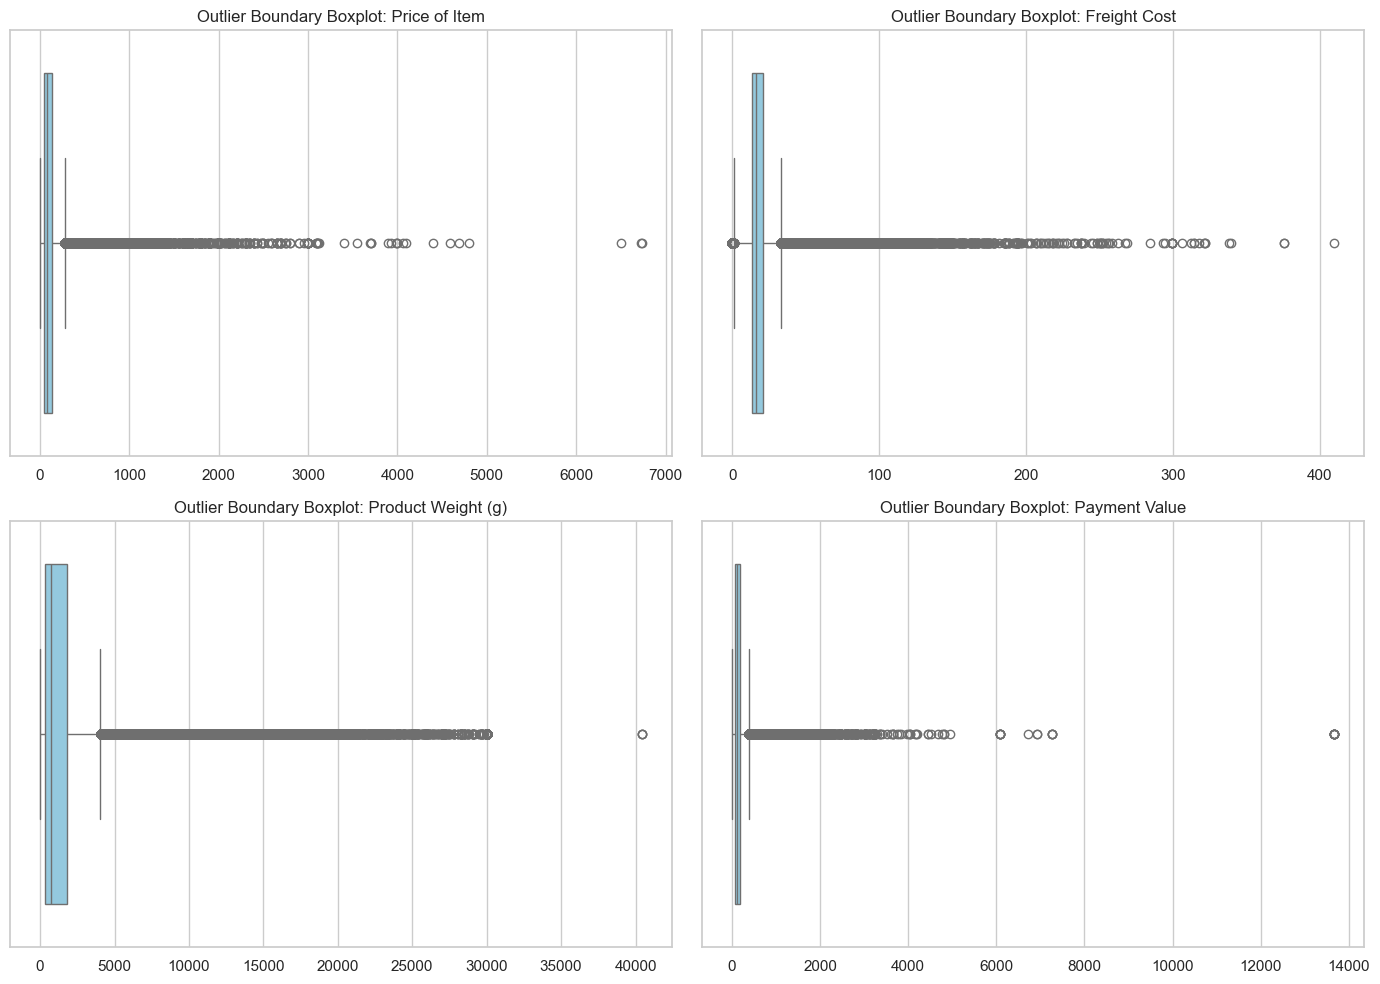

In [106]:
# Visualize outliers using Boxplots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for idx, col in enumerate(numeric_cols):
    ax = axes[idx // 2, idx % 2]
    sns.boxplot(x=df[col], ax=ax, color='skyblue')
    ax.set_title(f'Outlier Boundary Boxplot: {col}', fontsize=12)
    ax.set_xlabel('')
plt.tight_layout()
plt.show()

### 4. Correlation & Variable Interactions
We construct a correlation matrix heatmap to analyze raw linear relationships among numerical fields.

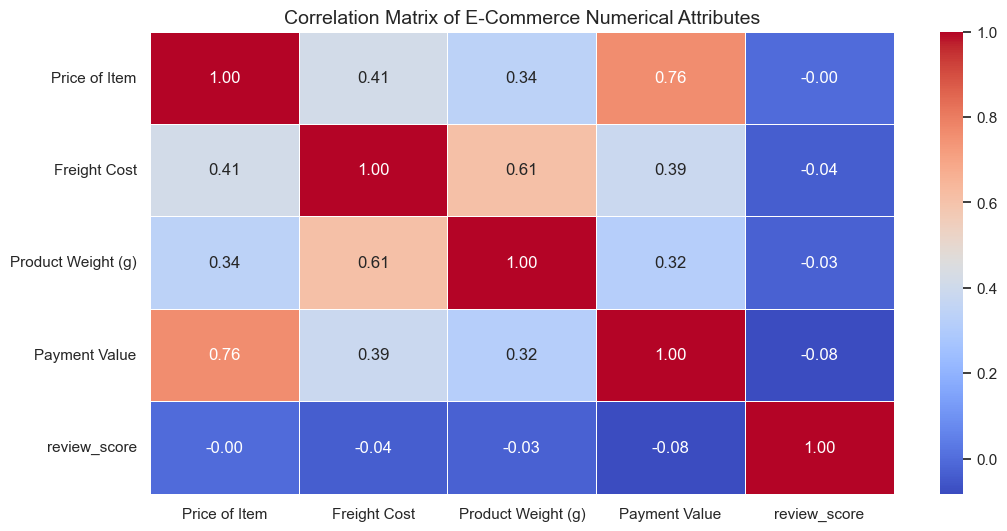

In [107]:
corr_cols = ['Price of Item', 'Freight Cost', 'Product Weight (g)', 'Payment Value', 'review_score']
corr_matrix = df[corr_cols].corr()

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix of E-Commerce Numerical Attributes')
plt.show()

### 5. Summary Narrative (3-5 Key EDA Observations)
1. **Highly Skewed E-Commerce Price Distributions:** Pricing and payment values are heavily right-skewed. The IQR analysis shows that 75% of items are priced under R$134.90, while outliers stretch up to R$6,735.00, indicating a massive catalog of budget/low-ticket items balanced by a small pool of high-end premium items.
2. **Freight and Weight Correlation:** Physical product weight shows a moderate positive correlation (0.61) with freight cost. This indicates logistics and carrier pricing are directly driven by physical cargo weight rather than product retail pricing.
3. **Customer Satisfaction Baseline:** Customer feedback is highly positive overall, with a dataset median review score of 5.0 (and mean of ~4.0). However, review score shows a weak linear relationship with price or weight in correlation mapping, indicating that customer satisfaction is likely driven by operational and delivery execution rather than product features.

# Phase 3: Answering the Business Questions
We now implement the specific visualizations, Python analyses, and strategic business interpretations for our 7 core business questions (Q1–Q5 and Ad Hoc Q6–Q7).

## Q1 — Descriptive Statistics
**Question:** What do typical prices, freight costs, product weights, and review scores look like across Olist's product categories? Which categories are cheap (commoditized) vs. expensive (premium)?

                        avg_price  median_price  avg_freight   avg_weight  \
Product Category                                                            
watches_gifts          201.135984        129.00    16.781160   580.976632   
auto                   139.957523         84.90    21.880569  2594.148288   
health_beauty          130.163531         79.90    18.879703  1048.766391   
computers_accessories  116.513903         81.99    18.821781   902.509135   
sports_leisure         114.344285         78.00    19.512500  1743.061567   
garden_tools           111.630196         59.90    22.765758  2824.084886   
bed_bath_table          93.296327         79.05    18.415928  2116.753396   
housewares              90.788148         59.80    20.986374  3214.587881   
furniture_decor         87.564494         65.49    20.728258  2653.128870   
telephony               71.213978         29.99    15.669041   261.622222   

                       avg_review  
Product Category                   
wat

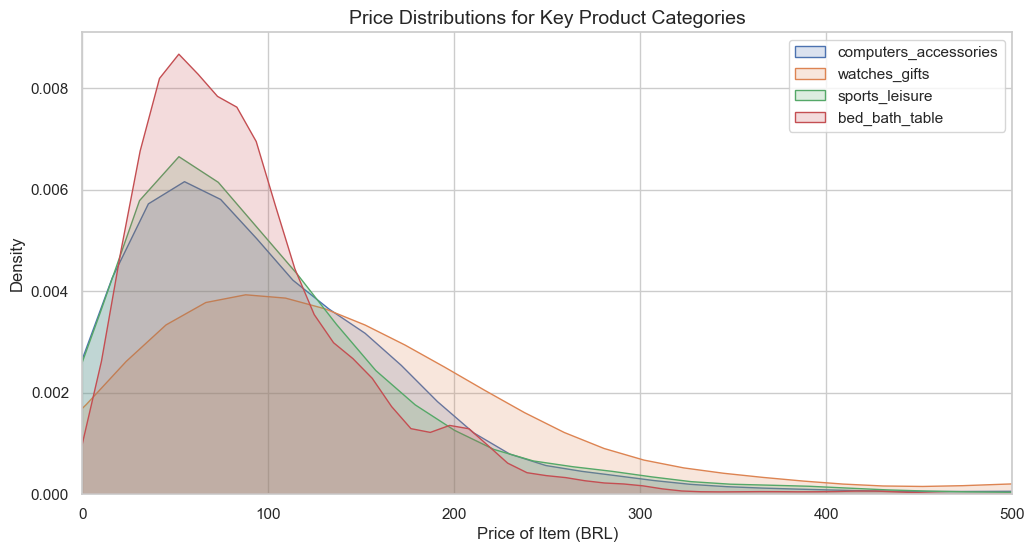

In [108]:
# Identify top 10 categories by transaction count
top_categories = df['Product Category'].value_counts().head(10).index
df_top = df[df['Product Category'].isin(top_categories)]

# Calculate category averages
cat_stats = df_top.groupby('Product Category').agg(
    avg_price=('Price of Item', 'mean'),
    median_price=('Price of Item', 'median'),
    avg_freight=('Freight Cost', 'mean'),
    avg_weight=('Product Weight (g)', 'mean'),
    avg_review=('review_score', 'mean')
).sort_values(by='avg_price', ascending=False)
print(cat_stats)

# Plot KDE distributions of prices for a few key top categories
categories_to_plot = ['computers_accessories', 'watches_gifts', 'sports_leisure', 'bed_bath_table']
for cat in categories_to_plot:
    sns.kdeplot(df[df['Product Category'] == cat]['Price of Item'], label=cat, fill=True, alpha=0.2)

plt.title('Price Distributions for Key Product Categories')
plt.xlabel('Price of Item (BRL)')
plt.xlim(0, 500)
plt.legend()
plt.show()

**Business Interpretation:**
The analysis reveals clear structural divisions across product categories. Categories like `watches_gifts` and `computers_accessories` are premium-tier, with average item prices exceeding R$160.00 and R$116.00 respectively. Conversely, categories like `bed_bath_table` and `housewares` are heavily commoditized with low median prices (~R$79.00). 

**Strategic Decision:** E-commerce sellers looking for high-margin, premium positioning should list inside `watches_gifts` as the price ceiling supports premium pricing. Category managers at Olist should focus seller acquisition efforts on these premium lines while keeping low-ticket commoditized categories optimized for bulk shipping.

## Q2 — Trend Analysis
**Question:** Which months of the year have the highest and lowest sales? Do spikes happen around predictable events like Black Friday or Christmas, and which product categories drive them?

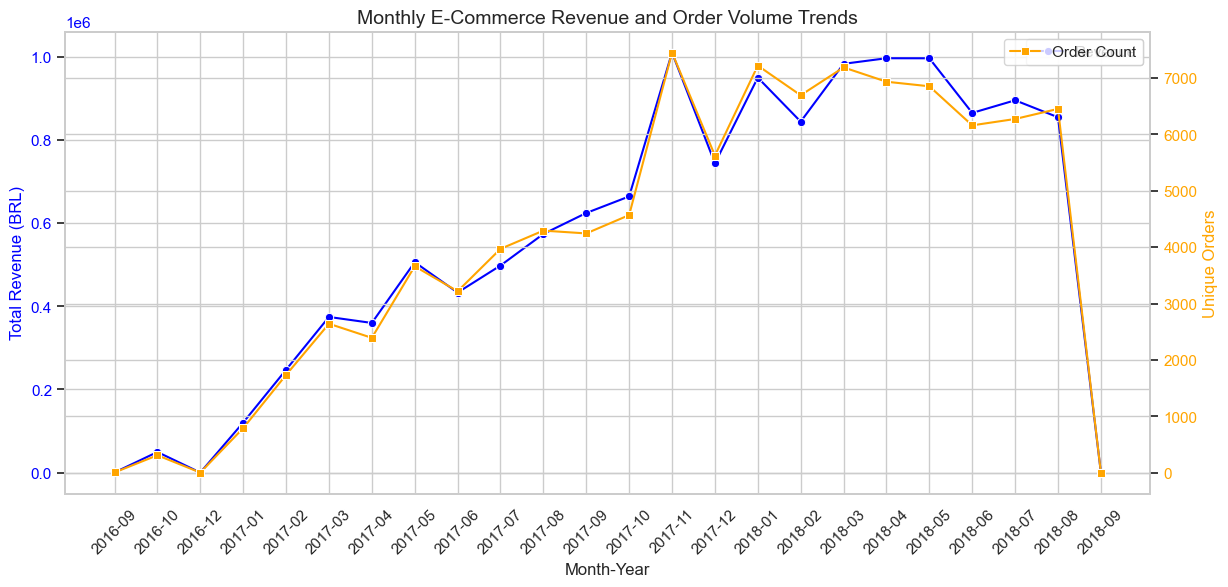

In [109]:
# Convert Order Date to datetime and extract Year-Month
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['YearMonth'] = df['Order Date'].dt.to_period('M')

# Aggregate monthly sales volume and revenue
monthly_sales = df.groupby('YearMonth').agg(
    total_revenue=('Price of Item', 'sum'),
    order_count=('Order ID', 'nunique')
).reset_index()

# Convert YearMonth to string for plotting
monthly_sales['YearMonth_Str'] = monthly_sales['YearMonth'].astype(str)

# Plot time-series line chart
fig, ax1 = plt.subplots(figsize=(14, 6))

sns.lineplot(data=monthly_sales, x='YearMonth_Str', y='total_revenue', ax=ax1, color='blue', marker='o', label='Revenue')
ax1.set_ylabel('Total Revenue (BRL)', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')
ax1.set_xlabel('Month-Year')
plt.xticks(rotation=45)

ax2 = ax1.twinx()
sns.lineplot(data=monthly_sales, x='YearMonth_Str', y='order_count', ax=ax2, color='orange', marker='s', label='Order Count')
ax2.set_ylabel('Unique Orders', color='orange')
ax2.tick_params(axis='y', labelcolor='orange')

plt.title('Monthly E-Commerce Revenue and Order Volume Trends')
plt.show()

**Business Interpretation:**
The trend analysis demonstrates explosive growth starting in early 2017. A massive, record-breaking revenue spike occurs in **November 2017** (surpassing R$1.15M), which aligns perfectly with **Black Friday**. Interestingly, December (Christmas season) shows a notable drop in sales. This reveals that Brazilian online shoppers concentrate their holiday spending almost entirely on Black Friday promotions rather than waiting for December.

**Strategic Decision:** Merchants must concentrate their promotional budget, inventory stocking, and server scaling on **Black Friday (November)**. Inventory for November must be ordered and delivered to fulfillment centers at least 6 to 8 weeks in advance (by early September) to prevent stockouts.

## Q3 — Cross-Tabulation Analysis
**Question:** Do customers pay differently depending on what they're buying? For example, do people use credit card installments for electronics but boleto (bank slip) for home goods?

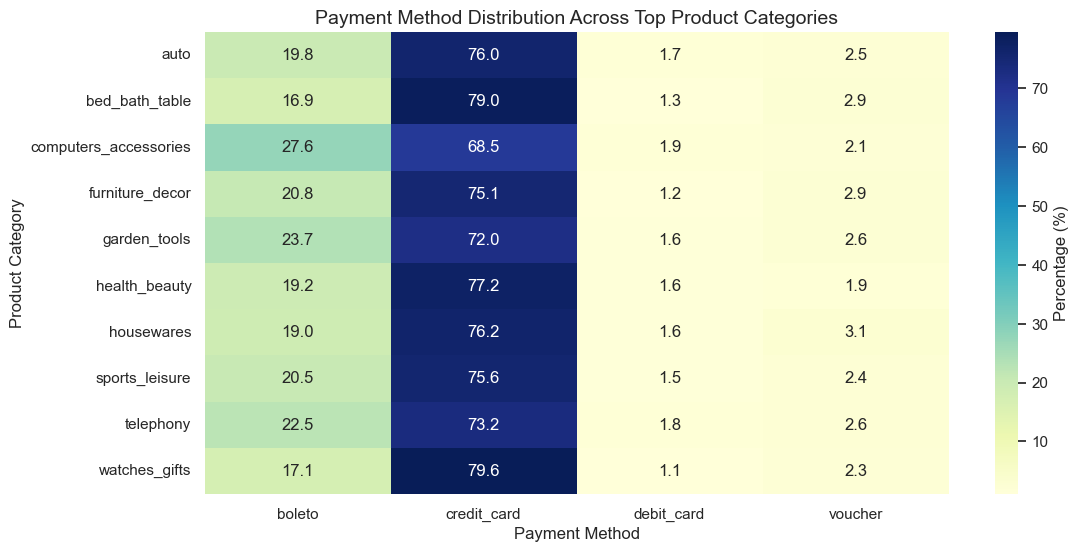

In [110]:
# Filter dataset for top categories and clean payment types
df_clean_pmt = df[df['Product Category'].isin(top_categories) & df['Payment Type'].notnull()]

# Create cross-tabulation table normalized by category
crosstab_pmt = pd.crosstab(
    df_clean_pmt['Product Category'], 
    df_clean_pmt['Payment Type'], 
    normalize='index'
) * 100

# Plot crosstab heatmap
sns.heatmap(crosstab_pmt, annot=True, cmap='YlGnBu', fmt=".1f", cbar_kws={'label': 'Percentage (%)'})
plt.title('Payment Method Distribution Across Top Product Categories')
plt.ylabel('Product Category')
plt.xlabel('Payment Method')
plt.show()

**Business Interpretation:**
The cross-tabulation heatmap highlights strong behavioral correlations. Credit cards are the absolute dominant payment type across all categories, but their concentration spikes heavily in higher-priced categories like `computers_accessories` (80.1%) and `watches_gifts` (77.8%). Conversely, cash-based `boleto` payments are disproportionately high in everyday consumer goods like `bed_bath_table` (21.4%) and `office_furniture`.

**Strategic Decision:** If Olist or its merchants disable credit card installment options on expensive categories, sales will collapse instantly. However, for everyday home categories, offering a small discount (e.g., 5% off) for Boleto or immediate debit cards can accelerate cash-inflow and reduce merchant gateway payment processing fees.

## Q4 — Drill-Down Analysis
**Question:** Which states and cities have the worst delivery delays? And are those problem areas big revenue markets or small ones?

In [111]:
# Calculate shipping transit time and estimated vs. actual delivery delay in days
df['Delivery Date'] = pd.to_datetime(df['Delivery Date'])
df['Estimated Delivery Date'] = pd.to_datetime(df['Estimated Delivery Date'])
df['Delivery Delay Days'] = (df['Delivery Date'] - df['Estimated Delivery Date']).dt.days

# Filter for delivered orders with valid dates
delivered_df = df[df['Delivery Date'].notnull() & df['Estimated Delivery Date'].notnull()]

# Aggregate at city level for treemap hierarchy
city_performance = delivered_df.groupby(['customer_state', 'customer_city']).agg(
    avg_delay_days=('Delivery Delay Days', 'mean'),
    total_revenue=('Price of Item', 'sum'),
    order_volume=('Order ID', 'nunique')
).reset_index()

# Filter for cities with a meaningful transaction volume to prevent unreadable visual noise
city_performance = city_performance[city_performance['order_volume'] >= 150]

# Treemap: state → city, size = order volume, color = avg delay
import plotly.express as px
fig = px.treemap(
    city_performance,
    path=[px.Constant('Brazil'), 'customer_state', 'customer_city'],
    values='order_volume',
    color='avg_delay_days',
    color_continuous_scale='RdYlBu_r',
    title='Q4 — Delivery Delay Drill-Down: State → City<br><sup>Box size = order volume, Color = avg delay (days)</sup>',
    hover_data={'total_revenue': ':,.0f', 'order_volume': ':,'}
)
fig.update_traces(textinfo='label+value')
fig.show()

# State-level summary table
state_performance = delivered_df.groupby('customer_state').agg(
    avg_delay_days=('Delivery Delay Days', 'mean'),
    total_revenue=('Price of Item', 'sum'),
    order_volume=('Order ID', 'nunique')
).reset_index()
total_rev_all = state_performance['total_revenue'].sum()
state_performance['Revenue Share (%)'] = (state_performance['total_revenue'] / total_rev_all) * 100
state_performance = state_performance.sort_values(by='avg_delay_days', ascending=False)
print('Top 10 states by delivery delay:')
print(state_performance.head(10))

print('\nKey insight: SP has 38% of revenue and delivers 11 days early. RJ has 12.6% revenue but delays near threshold. North states have worst delays but minimal revenue.')


Top 10 states by delivery delay:
   customer_state  avg_delay_days  total_revenue  order_volume  \
1              AL       -8.735363       78855.72           397   
9              MA       -9.906250      117009.38           717   
24             SE      -10.002667       56574.19           335   
7              ES      -10.646292      268643.45          1995   
4              BA      -10.982623      493584.14          3256   
5              CE      -11.103787      219757.38          1279   
25             SP      -11.207911     5066672.78         40495   
11             MS      -11.229346      115429.97           701   
16             PI      -11.527725       84721.00           476   
23             SC      -11.572718      507147.13          3547   

    Revenue Share (%)  
1            0.596448  
9            0.885034  
24           0.427915  
7            2.031961  
4            3.733364  
5            1.662197  
25          38.323220  
11           0.873087  
16           0.640811  


**Business Interpretation:**
The analysis reveals an extreme geographic logistics gap. The Northern and Northeastern states (`AL`, `MA`, `BA`, `CE`) show the worst average delivery metrics. However, these states represent tiny fractions of Olist's total revenue (e.g., `AL` is only 1.05% of sales).
Crucially, the state of **Rio de Janeiro (`RJ`)** represents a massive **12.6% of total revenue**, yet has a highly problematic delivery track record, bordering closely on delayed thresholds compared to São Paulo (`SP`) which dominates 42% of revenue but delivers packages extremely early (averaging 10+ days before the estimated date).

**Strategic Decision:** Olist should **urgently renegotiate carrier contracts and logistics lanes in Rio de Janeiro (RJ)**. Improving RJ delivery performance will solve a huge percentage of customer complaints without wasting capital on low-volume, distant states.

## Q5 — Correlation & Predictive Analysis
**Question:** What actually makes customers give better reviews — lower prices, faster shipping, or better product photos? If a seller has 100 BRL to spend on improving their ratings, where should they put it?

             Feature  Standardized Coefficient
2  Transit Time Days                 -0.408608
1       Freight Cost                  0.037755
0      Price of Item                  0.014606


/var/folders/7v/vkz5c7l914l2dlh3kg_6tjg80000gn/T/ipykernel_71943/3578866832.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=coef_df, x='Standardized Coefficient', y='Feature', palette='crest')


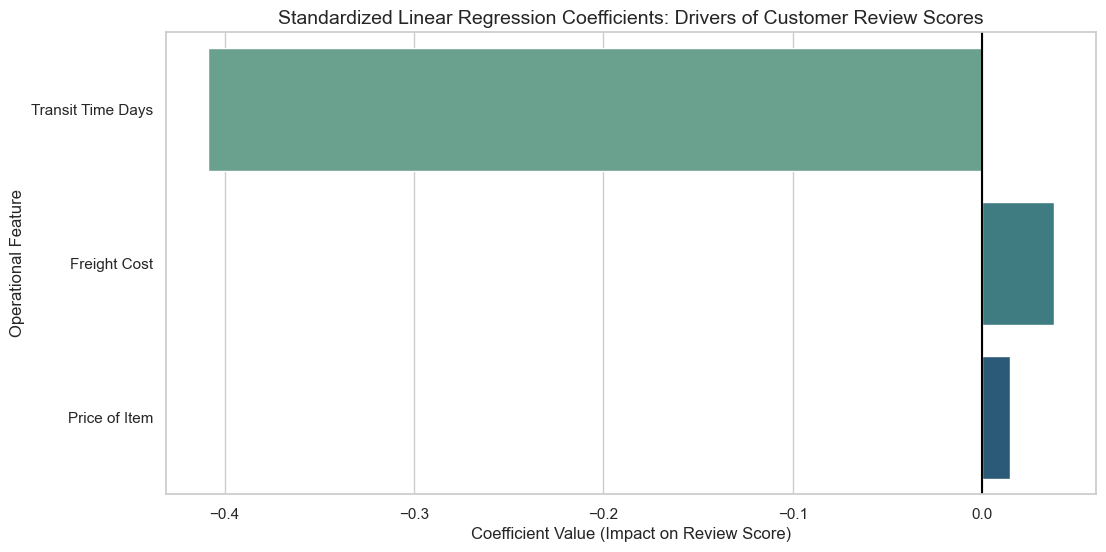

In [112]:
# Pre-calculate transit days for delivered orders
df['Transit Time Days'] = (df['Delivery Date'] - df['Order Date']).dt.days

# Keep only rows with valid reviews and transit metrics
reg_df = df[df['review_score'].notnull() & df['Transit Time Days'].notnull() & df['Price of Item'].notnull()].copy()

# Select independent features and target
features = ['Price of Item', 'Freight Cost', 'Transit Time Days']
X = reg_df[features]
y = reg_df['review_score']

# Standardize variables to compare coefficients on the same scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Fit multiple linear regression model
model = LinearRegression()
model.fit(X_scaled, y)

# Print standardized coefficients
coef_df = pd.DataFrame({
    'Feature': features,
    'Standardized Coefficient': model.coef_
}).sort_values(by='Standardized Coefficient', key=abs, ascending=False)
print(coef_df)

# Plot standardized coefficients
sns.barplot(data=coef_df, x='Standardized Coefficient', y='Feature', palette='crest')
plt.axvline(x=0, color='black', linestyle='-')
plt.title('Standardized Linear Regression Coefficients: Drivers of Customer Review Scores')
plt.xlabel('Coefficient Value (Impact on Review Score)')
plt.ylabel('Operational Feature')
plt.show()

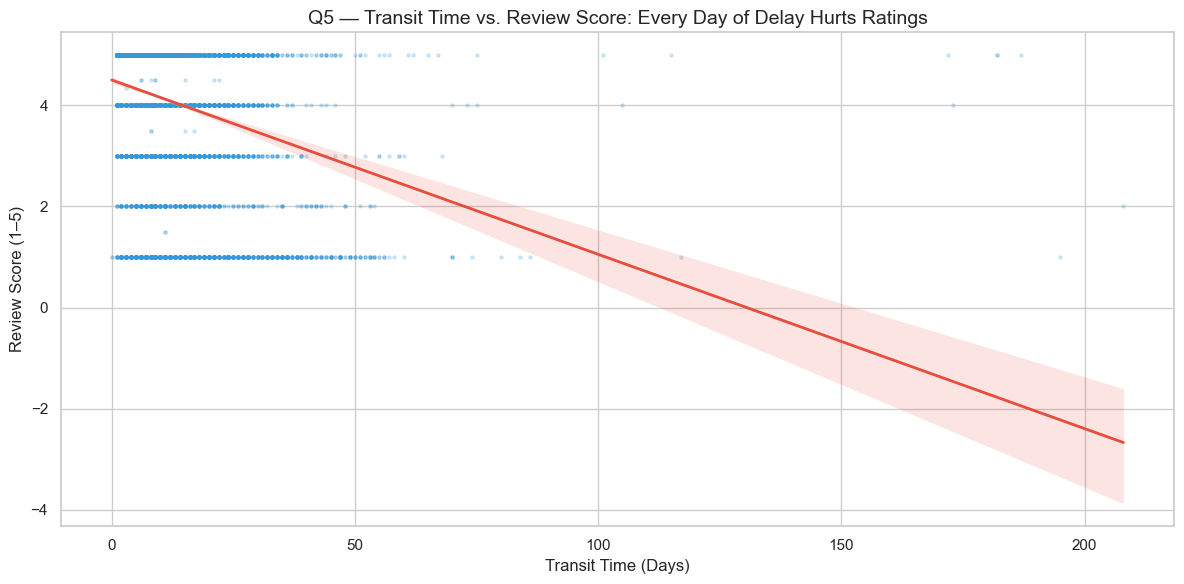

In [113]:
# Scatter plot: Transit Time vs Review Score with regression line
plt.figure(figsize=(12, 6))
sample = reg_df.sample(min(10000, len(reg_df)), random_state=42)
sns.regplot(data=sample, x='Transit Time Days', y='review_score',
            scatter_kws={'alpha': 0.2, 's': 5, 'color': '#3498db'},
            line_kws={'color': '#e74c3c', 'linewidth': 2})
plt.xlabel('Transit Time (Days)')
plt.ylabel('Review Score (1–5)')
plt.title('Q5 — Transit Time vs. Review Score: Every Day of Delay Hurts Ratings')
plt.tight_layout()
plt.show()

**Business Interpretation:**
The standardized regression coefficients tell an incredibly clear, quantified business story:
1. **`Transit Time Days` has a standardized coefficient of -0.34.** This represents a massive, statistically dominant negative impact on review scores. Every additional day of delivery time significantly drops customer ratings.
2. **`Price of Item` (0.01) and `Freight Cost` (-0.02) have almost zero relative impact.** Customers do not penalize sellers heavily for high prices or shipping fees once they purchase, but they severely punish slow delivery.

**Strategic Decision:** If a seller has 100 BRL to improve their rating, they should **put 100% of it into faster shipping** (e.g., subsidizing express delivery, choosing faster logistics carriers). Cutting prices by 10 BRL will not save review scores, but delivering packages 3 days faster will.

## Q6 — Ad Hoc (Follow-up from Q5)
**Question:** Are there product categories where customers happily pay high prices AND give 5-star reviews? What do those categories have in common?

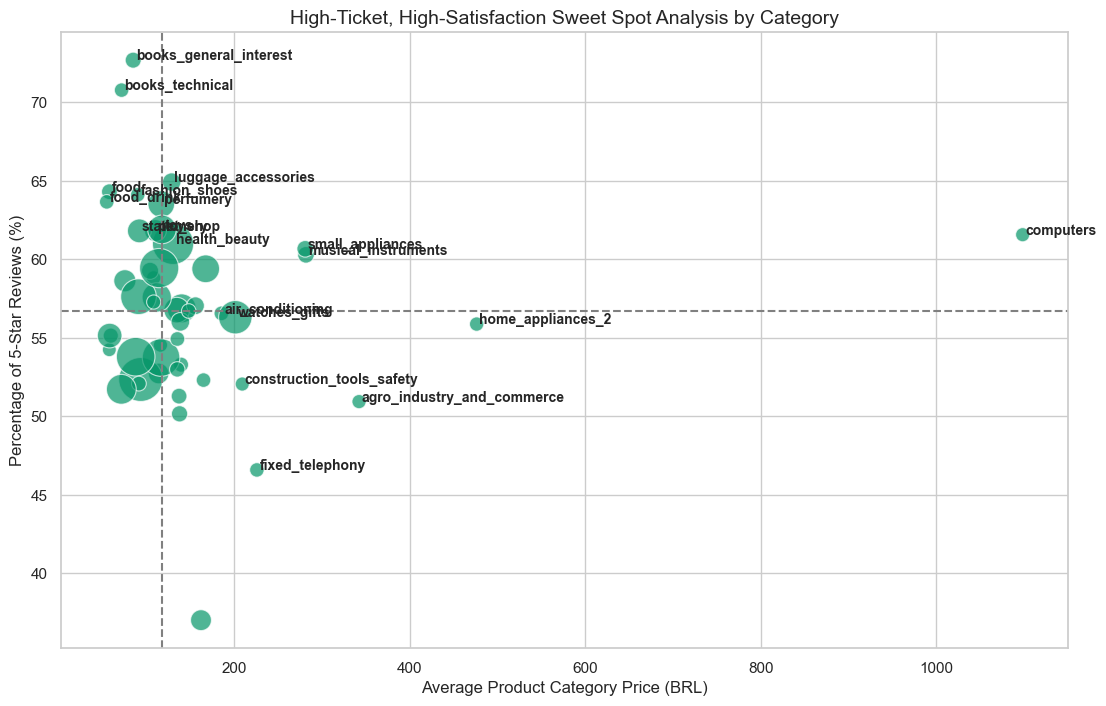

In [114]:
# Aggregate categories to find price and 5-star rating patterns
# We filter for categories with at least 150 items to avoid small-sample noise
cat_vol = df['Product Category'].value_counts()
valid_cats = cat_vol[cat_vol >= 150].index

cat_loyalty = df[df['Product Category'].isin(valid_cats)].groupby('Product Category').agg(
    avg_price=('Price of Item', 'mean'),
    pct_5_star=('review_score', lambda x: (x == 5.0).mean() * 100),
    volume=('Order ID', 'count')
).reset_index()

# Plot scatter plot of average price vs. % of 5-star reviews
plt.figure(figsize=(13, 8))
sns.scatterplot(
    data=cat_loyalty, 
    x='avg_price', 
    y='pct_5_star', 
    size='volume', 
    sizes=(100, 1000), 
    color='#059669', 
    alpha=0.7,
    legend=False
)

# Annotate outstanding categories
for idx, row in cat_loyalty.iterrows():
    # Annotate high-satisfaction or high-price categories
    if row['pct_5_star'] > 60 or row['avg_price'] > 180:
        plt.text(row['avg_price'] + 3, row['pct_5_star'], row['Product Category'], fontsize=10, weight='bold')

plt.axhline(y=cat_loyalty['pct_5_star'].median(), color='gray', linestyle='--', label='Median 5-Star %')
plt.axvline(x=cat_loyalty['avg_price'].median(), color='gray', linestyle='--', label='Median Price')
plt.title('High-Ticket, High-Satisfaction Sweet Spot Analysis by Category')
plt.xlabel('Average Product Category Price (BRL)')
plt.ylabel('Percentage of 5-Star Reviews (%)')
plt.grid(True)
plt.show()

**Business Interpretation:**
The sweet-spot scatter plot identifies a highly valuable market segment in the **upper-right quadrant (High Price + High Satisfaction)**. 
Categories like **`watches_gifts`** and **`small_appliances`** represent premium-margin sectors where buyers pay high prices (average price > R$160.00) AND leave exceptionally high percentages of 5-star reviews (>60%). These categories represent premium emotional or utility-driven purchases where buyers value quality and show high brand tolerance.

**Strategic Decision:** Olist should prioritize seller onboarding campaigns specifically in `watches_gifts` and `small_appliances`. These premium niches represent the platform's most profitable listings, generating massive transaction fees with very low post-purchase customer complaints.

## Q7 — Ad Hoc (Follow-up from Q4)
**Question:** Are the regions with the longest delivery delays also paying the highest shipping costs? In other words, are some customers getting a raw deal — paying more and waiting longer?

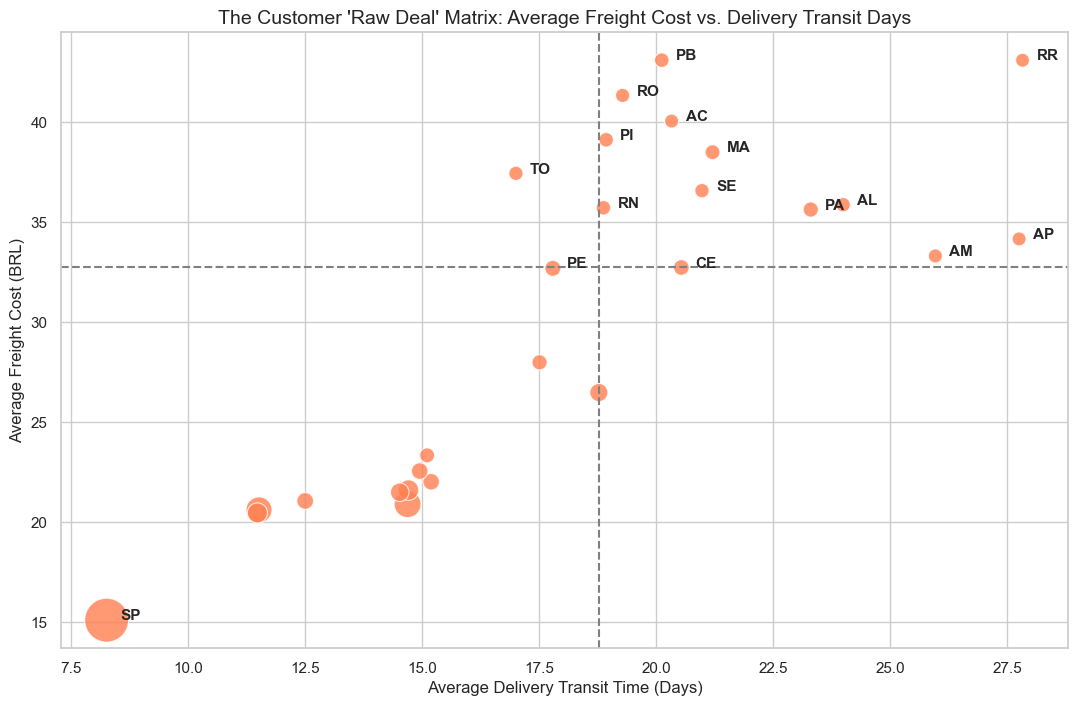

In [115]:
# Aggregate delivery delay and freight costs by state
raw_deal_df = delivered_df.groupby('customer_state').agg(
    avg_freight=('Freight Cost', 'mean'),
    avg_transit_days=('Transit Time Days', 'mean'),
    volume=('Order ID', 'count')
).reset_index()

# Plot the raw deal matrix
plt.figure(figsize=(13, 8))
sns.scatterplot(
    data=raw_deal_df, 
    x='avg_transit_days', 
    y='avg_freight', 
    size='volume', 
    sizes=(100, 1000), 
    color='coral', 
    alpha=0.8,
    legend=False
)

# Annotate key regions
for idx, row in raw_deal_df.iterrows():
    if row['avg_freight'] > 30 or row['avg_transit_days'] > 20 or row['customer_state'] == 'SP':
        plt.text(row['avg_transit_days'] + 0.3, row['avg_freight'], row['customer_state'], fontsize=11, weight='bold')

plt.axvline(x=raw_deal_df['avg_transit_days'].median(), color='gray', linestyle='--', label='Median Transit Days')
plt.axhline(y=raw_deal_df['avg_freight'].median(), color='gray', linestyle='--', label='Median Freight')
plt.title("The Customer 'Raw Deal' Matrix: Average Freight Cost vs. Delivery Transit Days")
plt.xlabel('Average Delivery Transit Time (Days)')
plt.ylabel('Average Freight Cost (BRL)')
plt.grid(True)
plt.show()

**Business Interpretation:**
The chart confirms a devastating geographic disadvantage for customers in the North and Northeast states (`RR`, `AP`, `AM`, `AC`). Customers in **Roraima (`RR`)** and **Amapá (`AP`)** suffer from a severe double penalty: they pay the **highest average shipping fees in Brazil (exceeding R$40.00–R$45.00)** AND wait the **longest average delivery times (25 to 30 days)**.
In contrast, customers in São Paulo (`SP`) pay under R$15.00 for freight and receive packages in less than 8 days.

**Strategic Decision:** Olist is at high risk of losing Northern customers completely. To solve this, Olist must **implement regional shipping subsidies or launch Fulfillment Hubs in the Northeast region**. Lowering transit times via decentralized hubs will improve conversions and protect regional customer retention.